## 1.Install libraries

In [ ]:
pip install vnstock3 --upgrade

In [ ]:
!pip install git+https://github.com/thinh-vu/vnstock.git

In [ ]:
pip install tensorflow pandas_ta mplcursors kaleido mplfinance matplotlib plotly scikit-learn statsmodels yfinance pandas "numpy==1.24.4" seaborn nbformat

## 2. Data

In [3]:
from vnstock import listing_companies
# Lấy danh sách tất cả mã cổ phiếu và tên công ty tương ứng
df = listing_companies()
print(df.head().to_string(index=False))# In dữ liệu trên cùng 1 dòng 

**Vui lòng chuyển đổi sang Vnstock3** thế hệ mới (3.2.1) với câu lệnh: `pip install vnstock3 --upgrade`.
**Từ 1/1/2025, vnstock3 sẽ được cài đặt khi sử dụng cú pháp** `pip install vnstock` **thay cho Vnstock Legacy** hiện tại.
Xem chi tiết [chuyển đổi sang vnstock3](https://vnstocks.com/docs/tai-lieu/migration-chuyen-doi-sang-vnstock3).
Phiên bản **Vnstock Legacy (0.2.9.2.3)** bạn đang sử dụng **sẽ không được nâng cấp thêm.**
Từ 7/10/2024 Vnstock giới thiệu nhóm Facebook Cộng đồng Vnstock, tham gia thảo luận tại đây: https://www.facebook.com/groups/vnstock.official

ticker comGroupCode                                            organName  organShortName organTypeCode comTypeCode              icbName                                                        icbNamePath    sector          industry             group             subgroup  icbCode  VN30  VNMID  VN100  VNSML  VNALL  HNX30  VNX50  VNXALL  VNDIAMOND  VNFINLEAD  VNFINSELECT  VNSI  VNCOND  VNCONS  VNENE  VNFIN  VNHEAL  VNIND  VNIT  VNMAT  VNREAL  VNUTI
   SSI         HOSE                      Công ty Cổ phần Chứng khoán SSI Chứng khoán SSI            DN          CK Môi giới chứng khoán Tài chính/Dịch vụ tài chính/Dịch vụ tài chính/Môi giới chứng khoán Tài chính Dịch vụ tài chính Dịch vụ tài chính Môi giới chứng khoán     8777  True  False   True  False   True  False   True    True      False       True         True False   False   False  False   True   False  False False  False   False  False
   BCM         HOSE Tổng Công ty Đầu tư và Phát triển Công nghiệp - CTCP     Becamex IDC            DN

In [4]:
from vnstock import company_overview
# Lấy thông tin của công ty
df = company_overview("VCG")
print(df.to_string(index=False))

ticker exchange             industry companyType  noShareholders  foreignPercent  outstandingShare  issueShare establishedYear  noEmployees  stockRating  deltaInWeek  deltaInMonth  deltaInYear shortName               industryEn  industryID industryIDv2                     website
   VCG     HOSE Xây dựng và Vật liệu          CT           35606           0.067             598.6       598.6            2006         3639          2.4       -0.032        -0.006        0.055 VINACONEX Construction & Materials         181         2357 http://www.vinaconex.com.vn


In [5]:
import pandas as pd
from vnstock import stock_historical_data
df = stock_historical_data(symbol="VCG", start_date="2024-01-01", end_date="2025-06-06", resolution="1D")
# Thêm cột Previous_Close để phục vụ model
df['Previous_Close'] = df['close'].shift(1)
df['Close_shifted'] = df['close'].shift(1)
df['Open_shifted'] = df['open'].shift(1)
df['High_shifted'] = df['high'].shift(1)
df['Low_shifted'] = df['low'].shift(1)

# Xóa các giá trị NaN/ missing value
df.dropna(inplace=True)

print(df.head().to_string(index=False))

      time  open  high   low  close   volume ticker  Previous_Close  Close_shifted  Open_shifted  High_shifted  Low_shifted
2024-01-03 20940 21930 20900  21630 12245600    VCG         21030.0        21030.0       21540.0       21540.0      20980.0
2024-01-04 21630 21680 21190  21330  9260800    VCG         21630.0        21630.0       20940.0       21930.0      20900.0
2024-01-05 21370 21590 21190  21370  7304300    VCG         21330.0        21330.0       21630.0       21680.0      21190.0
2024-01-08 21540 21800 21460  21500  8577600    VCG         21370.0        21370.0       21370.0       21590.0      21190.0
2024-01-09 21590 21630 21110  21240  5964700    VCG         21500.0        21500.0       21540.0       21800.0      21460.0


## 3. Indicator

In [ ]:
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import mplfinance as mpf
import matplotlib.dates as mdates
import os
import mplcursors

df['SMA_50'] = ta.sma(df['Close_shifted'], length=50)
df['EMA_50'] = ta.ema(df['Close_shifted'], length=50)
df['RSI'] = ta.rsi(df['Close_shifted'], length=14)

macd = ta.macd(df['Close_shifted'], fast=12, slow=26, signal=9)

df['MACD'] = macd['MACD_12_26_9']
df['Signal_Line'] = macd['MACDs_12_26_9']
df['MACD_Hist'] = macd['MACDh_12_26_9']

# Đảm bảo datetime index cho mplfinance
df['time'] = pd.to_datetime(df['time'])  # nếu chưa làm bước này
df.set_index('time', inplace=True)

#Vẽ biểu đồ Nến trước, rồi mới vẽ MACD & RSI
mpf_fig, mpf_axes = mpf.plot(
    df,
    type='candle',
    style='charles',
    volume=False,
    addplot=[
        mpf.make_addplot(df["SMA_50"], color='blue', linestyle='dotted'),
        mpf.make_addplot(df["EMA_50"], color='red', linestyle='dashed')
    ],
    returnfig=True,  
    figsize=(12, 6),
    tight_layout=True,
    datetime_format='%Y-%m-%d',
    xrotation=45
)

#Vẽ thêm MACD và RSI trên plt.subplots()
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 2]})
plt.subplots_adjust(hspace=0.5)

#Biểu đồ MACD
axes[0].plot(df.index, df["MACD"], label="MACD", color="blue")
axes[0].plot(df.index, df["Signal_Line"], label="Signal Line", color="red")
axes[0].bar(df.index, df["MACD_Hist"], label="Histogram", color=['green' if val >= 0 else 'red' for val in df["MACD_Hist"]])
axes[0].legend()
axes[0].set_title("MACD", fontsize=12)

#Biểu đồ RSI
axes[1].plot(df.index, df["RSI"], label="RSI 14", color="purple")
axes[1].axhline(70, linestyle="--", color="red", alpha=0.7, label="Overbought")
axes[1].axhline(30, linestyle="--", color="green", alpha=0.7, label="Oversold")
axes[1].set_ylim(0, 100)  # Giới hạn RSI từ 0 - 100
axes[1].legend()
axes[1].set_title("RSI 14", fontsize=12)

for ax in axes:
    ax.tick_params(axis='both', labelsize=10)

#Lưu và mở ảnh
plt.savefig("stock_analysis.png", dpi=300, bbox_inches="tight")
os.startfile("stock_analysis.png")

plt.show()

##  4. Using model to predict stocks 

### 4.1.OLS

In [30]:
pip install "numpy>=2.0"

  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.0.2 which is incompatible.


In [31]:
pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Loại bỏ NaN
df = df.dropna().copy()

# Thiết lập cửa sổ trượt để lấy dữ liệu 
window_size = 30

results = {'predictions': [], 'actual': [], 'daily_mae': []}

for i in range(window_size, len(df) - 1):
    train_df = df.iloc[i - window_size:i]  
    test_index = i + 1                    
    actual_close_price = df['close'].iloc[test_index]  

    X_train = train_df[['Previous_Close']]
    y_train = train_df['close']
    X_train = sm.add_constant(X_train)  # Thêm bias
    
    model = sm.OLS(y_train, X_train).fit()

    X_test = pd.DataFrame([[df['Previous_Close'].iloc[test_index]]], columns=['Previous_Close'])
    X_test = sm.add_constant(X_test)
    X_test = sm.add_constant(X_test, has_constant='add')

    prediction = model.predict(X_test)[0]

    results['predictions'].append(prediction)
    results['actual'].append(actual_close_price)
    daily_mae = mean_absolute_error([actual_close_price], [prediction])

    results['daily_mae'].append(daily_mae)

In [7]:
# In kết quả dự đoán
last_pred = results['predictions'][-1]
last_actual = results['actual'][-1]
print(f"\n Dự đoán giá đóng cửa ngày tiếp theo: {last_pred:.2f}")
print(f" Giá thực tế: {last_actual:.2f}")

#Tính toán hiệu suất mô hình
mae = mean_absolute_error(results['actual'], results['predictions'])
mse = mean_squared_error(results['actual'], results['predictions'])

print(f"\n Hiệu suất mô hình:")
print(f" MAE (Mean Absolute Error): {mae:.2f}")
print(f" MSE (Mean Squared Error): {mse:.2f}")


 Dự đoán giá đóng cửa ngày tiếp theo: 22190.94
 Giá thực tế: 21950.00

 Hiệu suất mô hình:
 MAE (Mean Absolute Error): 255.25
 MSE (Mean Squared Error): 143282.87


### 4.2. LSTM

In [8]:
#chi lay thong tin can thiet
df_lstm = df[['time','close']]
df_lstm.loc[:, 'time'] = pd.to_datetime(df_lstm['time'])

In [9]:
import pandas as pd
import datetime

# Hàm chuyển đổi từ datetime (hoặc str) thành datetime
def timestamp_to_datetime(date_val):
    if isinstance(date_val, str):
        date_val = pd.to_datetime(date_val)  # Nếu là chuỗi, chuyển đổi thành datetime
    return datetime.datetime(date_val.year, date_val.month, date_val.day)

# Chuyển đổi cột 'time' thành datetime nếu chưa phải
df_lstm['time'] = pd.to_datetime(df_lstm['time'], errors='coerce')  # Đảm bảo 'time' là datetime
df_lstm['time'] = df_lstm['time'].apply(timestamp_to_datetime)

# Đặt 'time' làm index
df_lstm.index = df_lstm.pop('time')


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


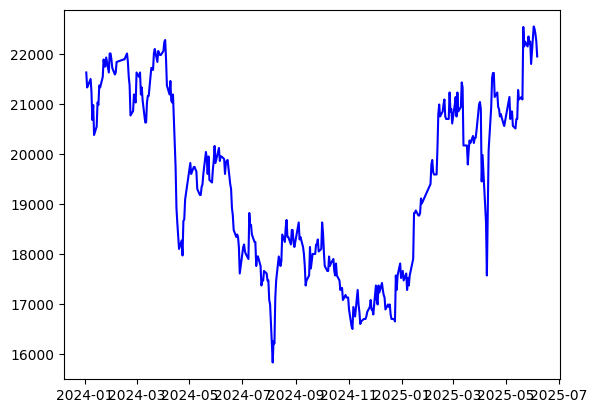

In [10]:
import matplotlib.pyplot as plt
plt.plot(df_lstm.index,df_lstm['close'], label='Giá thực tế', color='blue')

In [11]:
import pandas as pd
import numpy as np

def df_to_windowed_df(data, first_date, last_date, n=30, target_column='close'):
    """
    Tạo DataFrame theo dạng cửa sổ thời gian cho LSTM.
    
    Parameters:
        data (pd.DataFrame): Dữ liệu gốc với chỉ số là datetime và cột giá trị.
        first_date (str or datetime): Ngày bắt đầu.
        last_date (str or datetime): Ngày kết thúc.
        n (int): Số bước thời gian trong quá khứ (window size).
        target_column (str): Tên cột dùng làm giá trị dự đoán.
    
    Returns:
        pd.DataFrame: DataFrame với n cột input là dữ liệu n ngày trước đó và 1 cột target là dữ liệu ngày hiện tại.
    """
    # Chuyển đổi định dạng ngày
    first_date = pd.to_datetime(first_date)
    last_date = pd.to_datetime(last_date)

    # Giới hạn phạm vi ngày theo dữ liệu có sẵn, tránh tràn/ thiếu dữ liệu
    first_date = max(first_date, data.index.min())
    last_date = min(last_date, data.index.max())

    # Lấy ra các ngày hợp lệ
    valid_data = data.loc[first_date:last_date][[target_column]].dropna()
    valid_dates = valid_data.index

    window_size = n + 1
    total_windows = len(valid_dates) - window_size + 1

    if total_windows <= 0:
        return pd.DataFrame()  # Không đủ dữ liệu

    X = np.empty((total_windows, n), dtype=np.float32)
    Y = np.empty(total_windows, dtype=np.float32)
    dates = []

    for i in range(total_windows):
        window = valid_data.iloc[i:i+window_size][target_column].values
        X[i] = window[:-1]
        Y[i] = window[-1]
        dates.append(valid_dates[i + window_size - 1])

    # Tạo DataFrame kết quả
    windowed_df = pd.DataFrame({'Target_date': dates})
    for j in range(n):
        windowed_df[f'Target-{n-j}'] = X[:, j]
    windowed_df['Target'] = Y

    return windowed_df

windowed_df = df_to_windowed_df(df_lstm, '2024-01-01', '2025-04-14', n=30, target_column='close')
print(windowed_df.head())

  Target_date  Target-30  Target-29  Target-28  Target-27  Target-26  \
0  2024-02-21    21630.0    21330.0    21370.0    21500.0    21240.0   
1  2024-02-22    21330.0    21370.0    21500.0    21240.0    20680.0   
2  2024-02-23    21370.0    21500.0    21240.0    20680.0    20980.0   
3  2024-02-26    21500.0    21240.0    20680.0    20980.0    20380.0   
4  2024-02-27    21240.0    20680.0    20980.0    20380.0    20550.0   

   Target-25  Target-24  Target-23  Target-22  ...  Target-9  Target-8  \
0    20680.0    20980.0    20380.0    20550.0  ...   21890.0   21720.0   
1    20980.0    20380.0    20550.0    21030.0  ...   21720.0   21590.0   
2    20380.0    20550.0    21030.0    20980.0  ...   21590.0   21630.0   
3    20550.0    21030.0    20980.0    21370.0  ...   21630.0   21840.0   
4    21030.0    20980.0    21370.0    21330.0  ...   21840.0   21890.0   

   Target-7  Target-6  Target-5  Target-4  Target-3  Target-2  Target-1  \
0   21590.0   21630.0   21840.0   21890.0   218

In [12]:
def windowed_df_to_X_Y(windowed_df):
    """
    Chuyển DataFrame cửa sổ thành đầu vào cho mô hình LSTM.

    Parameters:
        windowed_df (pd.DataFrame): DataFrame chứa dữ liệu đã chia cửa sổ.

    Returns:
        X (ndarray): Dữ liệu đầu vào dạng (samples, timesteps, 1).
        Y (ndarray): Nhãn đầu ra dạng (samples,).
    """
    if windowed_df.empty:
        return np.array([]), np.array([])

    df_as_np = windowed_df.to_numpy()
    X = df_as_np[:, 1:-1].astype(np.float32)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    Y = df_as_np[:, -1].astype(np.float32)
    return X, Y

X, Y = windowed_df_to_X_Y(windowed_df)
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (286, 30, 1)
Y shape: (286,)


Train size: 228 samples (79.7%)
Validation size: 28 samples (9.8%)
Test size: 30 samples (10.5%)


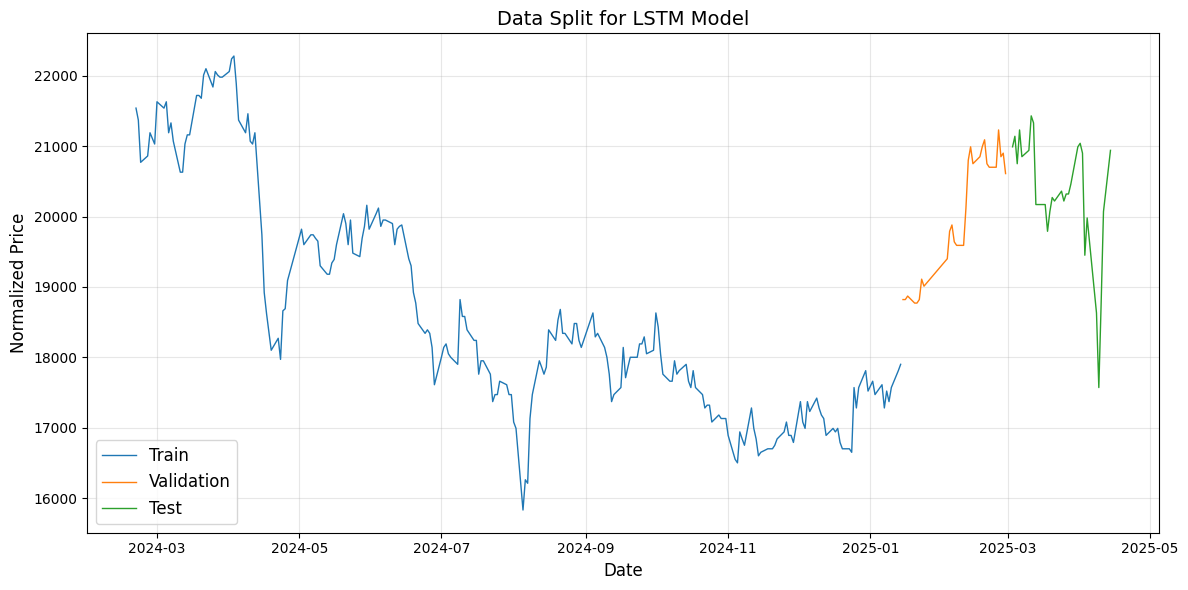

In [13]:
dates = windowed_df['Target_date'].to_numpy()

# Split data into train/val/test (80/10/10)
train_size = int(len(dates) * 0.8)
val_size = int(len(dates) * 0.1)

dates_train, X_train, Y_train = dates[:train_size], X[:train_size], Y[:train_size]
dates_val, X_val, y_val = dates[train_size:train_size+val_size], X[train_size:train_size+val_size], Y[train_size:train_size+val_size]
dates_test, X_test, y_test = dates[train_size+val_size:], X[train_size+val_size:], Y[train_size+val_size:]

# Create a more informative plot
plt.figure(figsize=(12, 6))
plt.plot(dates_train, Y_train, label='Train', linewidth=1)
plt.plot(dates_val, y_val, label='Validation', linewidth=1)
plt.plot(dates_test, y_test, label='Test', linewidth=1)

# Add plot formatting
plt.title('Data Split for LSTM Model', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Price', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Print split sizes
print(f"Train size: {len(dates_train)} samples ({len(dates_train)/len(dates):.1%})")
print(f"Validation size: {len(dates_val)} samples ({len(dates_val)/len(dates):.1%})")
print(f"Test size: {len(dates_test)} samples ({len(dates_test)/len(dates):.1%})")

In [2]:
pip uninstall -y tensorflow

Found existing installation: tensorflow 2.17.1
Uninstalling tensorflow-2.17.1:
  Successfully uninstalled tensorflow-2.17.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install tensorflow==2.14.0

  Using cached tensorflow-2.14.0-cp39-cp39-win_amd64.whl.metadata (3.3 kB)
  Using cached tensorflow_intel-2.14.0-cp39-cp39-win_amd64.whl.metadata (4.8 kB)
  Using cached ml_dtypes-0.2.0-cp39-cp39-win_amd64.whl.metadata (20 kB)
  Using cached wrapt-1.14.1-cp39-cp39-win_amd64.whl.metadata (6.7 kB)
  Using cached tensorboard-2.14.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached tensorflow_estimator-2.14.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached keras-2.14.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached google_auth-2.40.3-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached google_auth_oauthlib-1.0.0-py2.py3-none-any.whl.metadata (2.7 kB)
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached requests_oauthlib-2.0.0-py2.py3-none-any.whl.metadata (11 kB)
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 

Epoch 1/200
8/8 [==============================] - 3s 72ms/step - loss: 0.1898 - mae: 0.3766 - val_loss: 0.3365 - val_mae: 0.5683
Epoch 2/200
8/8 [==============================] - 0s 13ms/step - loss: 0.1738 - mae: 0.3580 - val_loss: 0.3070 - val_mae: 0.5427
Epoch 3/200
8/8 [==============================] - 0s 13ms/step - loss: 0.1520 - mae: 0.3326 - val_loss: 0.2766 - val_mae: 0.5149
Epoch 4/200
8/8 [==============================] - 0s 13ms/step - loss: 0.1356 - mae: 0.3100 - val_loss: 0.2455 - val_mae: 0.4849
Epoch 5/200
8/8 [==============================] - 0s 12ms/step - loss: 0.1124 - mae: 0.2796 - val_loss: 0.2117 - val_mae: 0.4500
Epoch 6/200
8/8 [==============================] - 0s 12ms/step - loss: 0.0966 - mae: 0.2530 - val_loss: 0.1757 - val_mae: 0.4096
Epoch 7/200
8/8 [==============================] - 0s 12ms/step - loss: 0.0732 - mae: 0.2122 - val_loss: 0.1380 - val_mae: 0.3627
Epoch 8/200
8/8 [==============================] - 0s 14ms/step - loss: 0.0487 - mae: 0.16

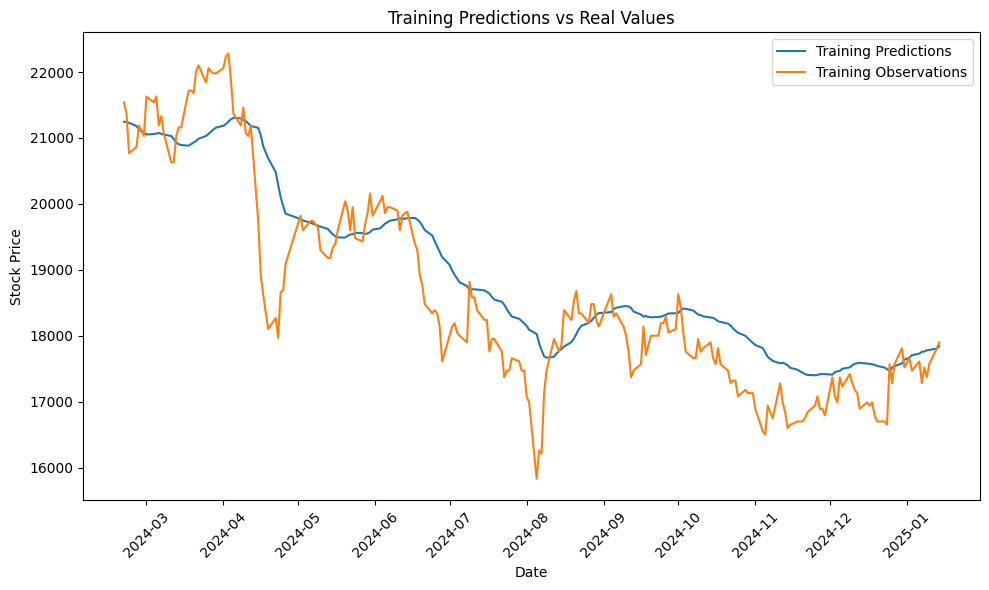

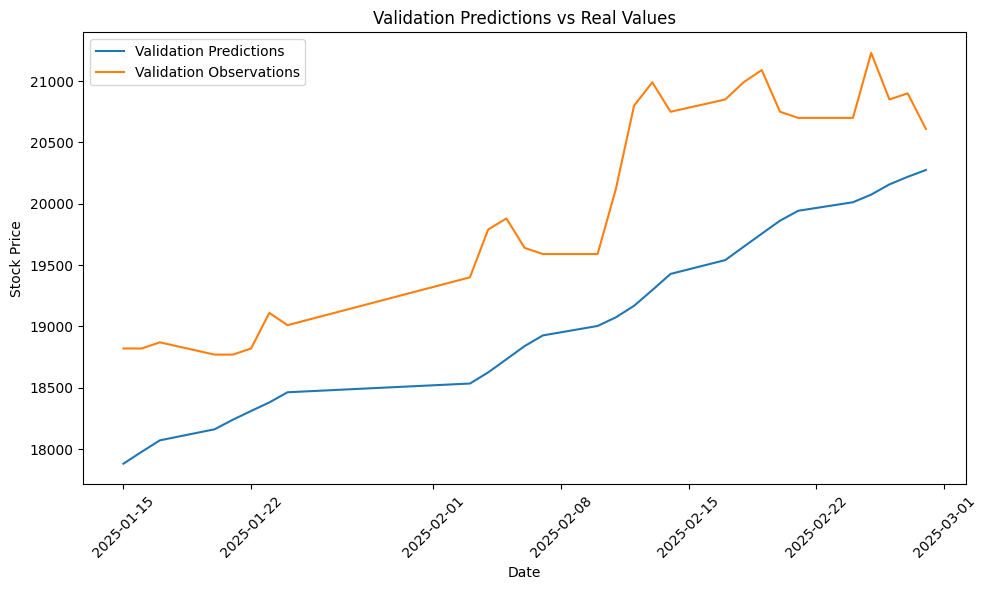

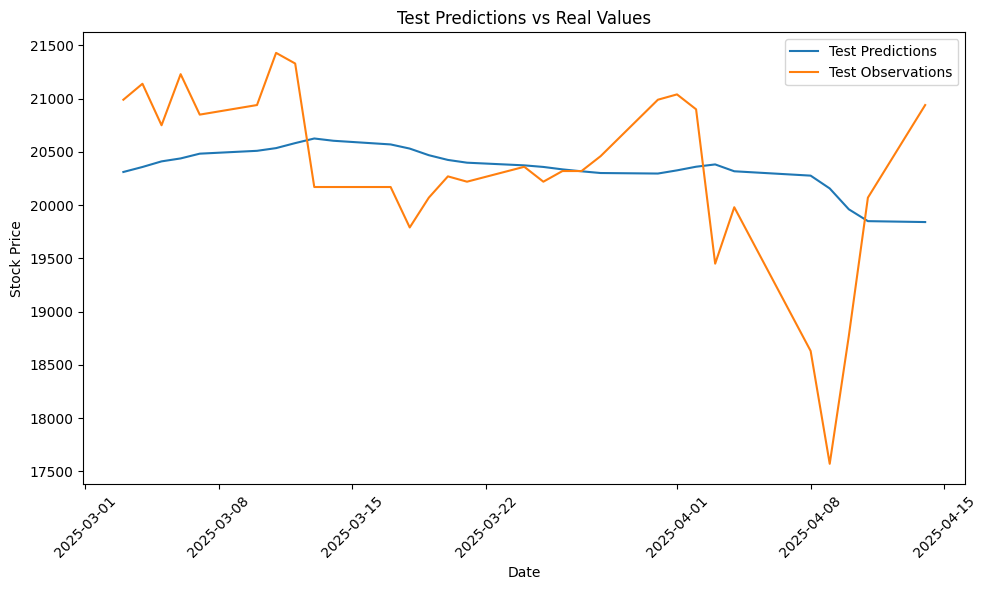

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Scale dữ liệu X và Y
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Xử lý và scale X_train và Y_train
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler_x.fit_transform(X_train_reshaped).reshape(X_train.shape)

# Scale Y_train
Y_train_scaled = scaler_y.fit_transform(Y_train.reshape(-1, 1))

# Scale X_val và y_val
X_val_reshaped = X_val.reshape(-1, X_val.shape[-1])
X_val_scaled = scaler_x.transform(X_val_reshaped).reshape(X_val.shape)
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1))

# Scale X_test và y_test
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler_x.transform(X_test_reshaped).reshape(X_test.shape)
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# Xây dựng mô hình LSTM
model = Sequential([
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='mse', 
              metrics=['mae'])

# Callback để dừng sớm nếu model không cải thiện
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Huấn luyện mô hình
history = model.fit(X_train_scaled, Y_train_scaled, 
                    validation_data=(X_val_scaled, y_val_scaled), 
                    epochs=200, 
                    batch_size=32,
                    callbacks=[early_stop])

# Dự đoán với X_train đã scale
train_predictions_scaled = model.predict(X_train_scaled).flatten()
train_predictions = scaler_y.inverse_transform(train_predictions_scaled.reshape(-1, 1)).flatten()

# Dự đoán với X_val đã scale
val_predictions_scaled = model.predict(X_val_scaled).flatten()
val_predictions = scaler_y.inverse_transform(val_predictions_scaled.reshape(-1, 1)).flatten()

# Dự đoán với X_test đã scale
test_predictions_scaled = model.predict(X_test_scaled).flatten()
test_predictions = scaler_y.inverse_transform(test_predictions_scaled.reshape(-1, 1)).flatten()

# Trích xuất giá trị Y_train ban đầu
Y_train = Y_train[:len(dates_train)]
y_val = y_val[:len(dates_val)]
y_test = y_test[:len(dates_test)]

# Vẽ biểu đồ riêng cho Training Predictions và Real Observations
plt.figure(figsize=(10, 6))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, Y_train)
plt.legend(['Training Predictions', 'Training Observations'])
plt.title("Training Predictions vs Real Values")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.xticks(rotation=45)  # Chỉnh chữ nghiêng
plt.tight_layout()
plt.show()

# Vẽ biểu đồ riêng cho Validation Predictions và Real Observations
plt.figure(figsize=(10, 6))
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])
plt.title("Validation Predictions vs Real Values")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.xticks(rotation=45)  # Chỉnh chữ nghiêng
plt.tight_layout()
plt.show()

# Vẽ biểu đồ riêng cho Test Predictions và Real Observations
plt.figure(figsize=(10, 6))
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Test Predictions', 'Test Observations'])
plt.title("Test Predictions vs Real Values")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.xticks(rotation=45)  # Chỉnh chữ nghiêng
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
mae_train = mean_absolute_error(Y_train, train_predictions)
mse_train = mean_squared_error(Y_train, train_predictions)

mae_val   = mean_absolute_error(y_val, val_predictions)
mse_val   = mean_squared_error(y_val, val_predictions)

mae_test  = mean_absolute_error(y_test, test_predictions)
mse_test  = mean_squared_error(y_test, test_predictions)

print(f"Train  MAE: {mae_train:.4f}, MSE: {mse_train:.4f}")
print(f"Val    MAE: {mae_val:.4f}, MSE: {mse_val:.4f}")
print(f"Test   MAE: {mae_test:.4f}, MSE: {mse_test:.4f}")

metrics_df = pd.DataFrame({
    "MAE": [mae_train, mae_val, mae_test],
    "MSE": [mse_train, mse_val, mse_test]
}, index=["Train", "Validation", "Test"])

df_pred = pd.DataFrame({
    "date":   np.concatenate([dates_train, dates_val, dates_test]),
    "split":  ["train"]*len(dates_train) + ["val"]*len(dates_val) + ["test"]*len(dates_test),
    "y_true": np.concatenate([Y_train, y_val, y_test]),
    "y_pred": np.concatenate([train_predictions, val_predictions, test_predictions]),
})

metrics_df.to_csv(
    r"C:\Users\ntlinh\OneDrive - Hanoi University of Science and Technology\Documents\20242\Pro2\metrics_summary.csv",
    index=True
)
print("Saved metrics to metrics_summary.csv")

df_pred.to_csv(
    r"C:\Users\ntlinh\OneDrive - Hanoi University of Science and Technology\Documents\20242\Pro2\predictions.csv",
    index=False
)
print("Saved full predictions to predictions.csv")

Train  MAE: 550.2621, MSE: 514842.6562
Val    MAE: 914.7280, MSE: 954281.1250
Test   MAE: 602.7450, MSE: 639953.3125
Saved metrics to metrics_summary.csv
Saved full predictions to predictions.csv


### 4.3.TimeGPT

In [21]:
pip install nixtla>=0.5.1

Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install prophet

   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/13.3 MB 6.7 MB/s eta 0:00:02
   --------- ------------------------------ 3.1/13.3 MB 9.2 MB/s eta 0:00:02
   ---------------- ----------------------- 5.5/13.3 MB 10.2 MB/s eta 0:00:01
   ---------------------- ----------------- 7.6/13.3 MB 10.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.7/13.3 MB 10.2 MB/s eta 0:00:01
   ------------------------------------ --- 12.1/13.3 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 13.3/13.3 MB 9.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/991.0 kB ? eta -:--:--
   ---------------------------------------- 991.0/991.0 kB 9.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
ERROR:nixtla.nixtla_client:Attempt 1 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 2 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 3 failed with error: status_code: 429, body: {'detail': 'You have reached your request limit per month, email ops@nixtla.io to increase your usage limit or wait until next month'}
ERROR:nixtla.nixtla_client:Attempt 4 failed with error: status_code: 429, bo

⚠️ Quota Nixtla hết, sử dụng Prophet fallback.


DEBUG:cmdstanpy:Adding TBB (c:\Users\ntlinh\.conda\envs\my_env\lib\site-packages\prophet\stan_model\cmdstan-2.33.1\stan\lib\stan_math\lib\tbb) to PATH
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: C:\Users\ntlinh\AppData\Local\Temp\tmpop4c6h_s\36cd5rc_.json
DEBUG:cmdstanpy:input tempfile: C:\Users\ntlinh\AppData\Local\Temp\tmpop4c6h_s\c36wauyr.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\ntlinh\\.conda\\envs\\my_env\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=586', 'data', 'file=C:\\Users\\ntlinh\\AppData\\Local\\Temp\\tmpop4c6h_s\\36cd5rc_.json', 'init=C:\\Users\\ntlinh\\AppData\\Local\\Temp\\tmpop4c6h_s\\c36wauyr.json', 'output', 'file=C:\\Users\\ntlinh\\AppData\\Local\\Temp\\tmpop4c6h_s\\prophet_model0rek0xyd\\prophet_model-20250609203754.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=

MAE: 481.8320
MSE: 391695.8149

Sample predictions:
      date  y_true       y_pred
2024-01-03 21630.0 21554.003228
2024-01-04 21330.0 21544.514434
2024-01-05 21370.0 21484.180625
2024-01-06 21370.0 21478.402687
2024-01-07 21370.0 21477.157334
2024-01-08 21500.0 21514.485070
2024-01-09 21240.0 21540.201364
2024-01-10 20680.0 21546.066318
2024-01-11 20980.0 21536.577524
2024-01-12 20380.0 21476.243714

Saved evaluation results to:
C:\Users\ntlinh\OneDrive - Hanoi University of Science and Technology\Documents\20242\Pro2\forecast_eval.csv


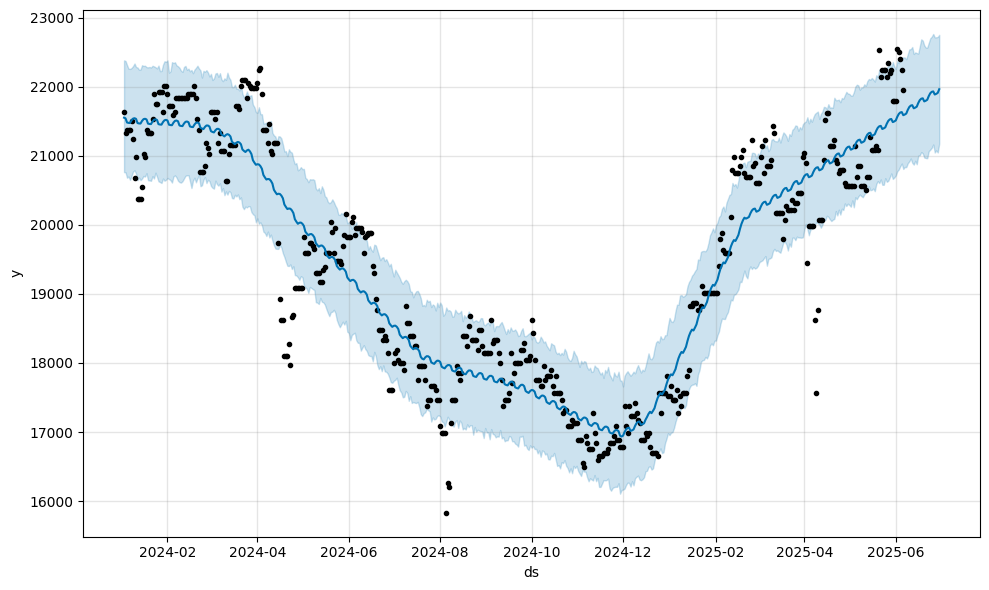

In [16]:
from nixtla.nixtla_client import NixtlaClient, ApiError
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Khởi tạo client Nixtla
nixtla_client = NixtlaClient(
    api_key="nixak-XZNxaPQCR93NPPywAL5rFS1MqcWnVxRrzOQgQwdOBf1ffrkq5tUb7xNlygWS2tWb5gfey1nd6NLCDxdv"
)

# 2. Chuẩn bị df_gpt
df_gpt = df[["time","close"]].rename(columns={"time":"ds","close":"y"})
df_gpt["ds"] = pd.to_datetime(df_gpt["ds"])
df_gpt = (
    df_gpt.sort_values("ds")
          .drop_duplicates("ds")
          .set_index("ds")
          .asfreq("D")     # tạo đủ khung ngày hàng ngày
          .reset_index()
)
df_gpt["y"] = df_gpt["y"].ffill()

# 3. Forecast và vẽ, với fallback Prophet khi hết quota
try:
    fcst_df = nixtla_client.forecast(df_gpt, h=24, freq="D", level=[80,90])
    nixtla_client.plot(df_gpt, fcst_df, level=[80,90])
    
    # Đưa 'yhat' từ Nixtla vào đánh giá
    df_eval = pd.concat([
        df_gpt.set_index("ds")["y"],
        fcst_df.set_index("ds")["yhat"]
    ], axis=1).dropna()
    df_eval.columns = ["y_true","y_pred"]
    
except ApiError as e:
    if e.status_code == 429:
        print("⚠️ Quota Nixtla hết, sử dụng Prophet fallback.")
        m = Prophet(daily_seasonality=True)
        m.fit(df_gpt)
        future = m.make_future_dataframe(periods=24, freq="D")
        forecast = m.predict(future)
        fig = m.plot(forecast)
        
        # Đánh giá trên chính tập lịch sử
        df_eval = pd.concat([
            df_gpt.set_index("ds")["y"],
            forecast.set_index("ds")["yhat"]
        ], axis=1).dropna()
        df_eval.columns = ["y_true","y_pred"]
    else:
        raise

# 4. Tính MAE/MSE
mae = mean_absolute_error(df_eval["y_true"], df_eval["y_pred"])
mse = mean_squared_error(df_eval["y_true"], df_eval["y_pred"])
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}\n")

# 5. In mẫu đầu
print("Sample predictions:")
print(df_eval.head(10).reset_index().rename(columns={"ds":"date"}).to_string(index=False))

# 6. Lưu kết quả đánh giá ra CSV (đường dẫn Windows raw-string)
output_path = r"C:\Users\ntlinh\OneDrive - Hanoi University of Science and Technology\Documents\20242\Pro2\forecast_eval.csv"
df_eval.reset_index().rename(columns={"ds":"date"}).to_csv(output_path, index=False)
print(f"\nSaved evaluation results to:\n{output_path}")
